## Python for DS Week-2 Notebook

### Table of Content
1.  **[Concatenate](#Concatenate)**
2.  **[Merging and Joining](#Merging)**
3.  **[Reshaping](#Reshaping)**
4.  **[Duplicate](#Duplicate)**
5.  **[Dropping Rows and Columns](#drop)**
6.  **[Rename](#Rename)**
7.  **[Map and Replace](#Map)**
8.  **[Value Counts](#Value_Counts)**
9.  **[Pivot Table](#Pivote)**
10.  **[Cross Table](#crosst)**
11. **[Groupby in Pandas](#Groupby)**
12. **[Summary Statistics](#Summary_Statistics)**
13. **[Date-Time-Functions](#Datetime)**
14. **[to_csv](#to_csv)**
15. **[Plots using Matplotlib ](#matplotlib)**
16. **[Plots using Seaborn ](#seaborn)**
17. **[Plots using Plotly(3D Plots)](#plotly)**

<a id="Concatenate"> </a>
### 1. Concatenate

Concatenation is a process of joining objects along a particular axis, with set logic applied along the other axes.

**Concatenating DataFrames**

To concatenate DataFrames, let us first create three DataFrame
1. df_prof_info_2024: professional information on employees of year 2024
2. df_prof_info_2025: professional information on employees of year 2025
3. df_pers_info_2024: personal information on employees of year 2024
4. df_pers_info_2025: personal information on employees of year 2025


In [57]:
import pandas as pd

In [58]:
# create a DataFrame from a dictionary
df_prof_info_2024 = pd.DataFrame({
   'Emp_ID': [1001,1002,1003,1004,1005],
   'Name': ['Alex', 'Amy', 'Allen', 'Alice', 'Stephan'],
   'Gender':['M', 'F', 'M', 'F', 'M'],
   'Salary':[67000,90000,87000,69000,78000]})


# create a DataFrame from a dictionary
df_prof_info_2025 = pd.DataFrame({
    'Emp_ID': [1006,1007,1008,1009,1010,1011],
   'Name': ['Billy', 'Brian', 'Bran', 'Bryce', 'Betty','James'],
    'Gender':['M', 'M', 'M', 'F', 'F','M'],
   'Salary':[89000,80000,79000,97000,88000,89000]})


# create a DataFrame from a dictionary
df_pers_info_2024 = pd.DataFrame({
     'Emp_ID': [1001,1002,1003,1004,1005],
   'Hometown': ['New York', 'London', 'San Francisco', 'Seattle', 'Madrid'],
    'Marital':['Married','Divorsed','Single','Married','Single'],
   'Dependents':[1,1,3,2,1]})


# create a DataFrame from a dictionary
df_pers_info_2025 = pd.DataFrame({
     'Emp_ID': [1006,1007,1008,1009,1010,1011],
   'Hometown': ['Paris', 'Boston', 'San Francisco', 'Seattle', 'London','London'],
    'Marital':['Married','Divorsed','Single','Married','Single','Single'],
   'Dependents':[1,1,3,2,1,2]})



In [59]:
final_prof_info = pd.concat([df_prof_info_2024, df_prof_info_2025], axis=0).reset_index()
final_pers_info = pd.concat([df_pers_info_2024, df_pers_info_2025], axis=0).reset_index()
pd.concat([final_pers_info, final_prof_info], axis=1)

,index,Emp_ID,Hometown,Marital,Dependents,index,Emp_ID,Name,Gender,Salary
0,0,1001,New York,Married,1,0,1001,Alex,M,67000
1,1,1002,London,Divorsed,1,1,1002,Amy,F,90000
2,2,1003,San Francisco,Single,3,2,1003,Allen,M,87000
3,3,1004,Seattle,Married,2,3,1004,Alice,F,69000
4,4,1005,Madrid,Single,1,4,1005,Stephan,M,78000
5,0,1006,Paris,Married,1,0,1006,Billy,M,89000
6,1,1007,Boston,Divorsed,1,1,1007,Brian,M,80000
7,2,1008,San Francisco,Single,3,2,1008,Bran,M,79000
8,3,1009,Seattle,Married,2,3,1009,Bryce,F,97000
9,4,1010,London,Single,1,4,1010,Betty,F,88000


**Concatenating pandas DataFrames using `.concat()`**

**Combine DataFrames vertically**
##### Logic we want combine the employee details of both the years

**Combine DataFrames horizontally**
##### We want to combine the prof details and personal details of employeees from year 2024

<a id="Merging"> </a>
### 2. Merging and Joining

Merging two datasets is a process of bringing two datasets to form one, by aligning the rows from both the datasets based on common attributes or columns

### Concatenate using `.merge()`

**`merge()` allows you to perform inner join, left join, right join, and full outer join in pandas.**

**Understanding the Different Types of Merge:**

Inner join: includes those rows that are common to both the DataFrames. (how=‘inner’).

Left outer join: includes all the rows of your DataFrame x and only those from y that match. (how=‘left’).

Right outer join: includes all the rows of your DataFrame y and only those from x that match. (how=‘right’).

Full outer join: includes all rows from both DataFrames. (how=‘outer’).

In [60]:
import pandas as pd

# Table 1: Professional Details
prof_data = {
    'emp_id': ['E101', 'E102', 'E103', 'E104', 'E105', 'E106'],
    'salary': [55000, 72000, 95000, 48000, 60000, 85000],
    'experience': ['3 years', '5 years', '8 years', '2 years', '4 years', '7 years'],
    'designation': ['Associate', 'Manager', 'Senior Manager', 'Associate', 'Manager', 'Senior Manager']
}

# Table 2: Personal Details
personal_data = {
    'emp_id': ['E101', 'E103', 'E104', 'E107', 'E108'],
    'gender': ['Male', 'Female', 'Male', 'Female', 'Male'],
    'phone_number': [9876543210, 8765432109, 7654321098, 6543210987, 5432109876]
}

# Creating DataFrames
df_prof = pd.DataFrame(prof_data)
df_personal = pd.DataFrame(personal_data)


**Inner Join:**<br>
It returns only the rows in which the left table has matching keys in the right table.

In [61]:
df_prof

,emp_id,salary,experience,designation
0,E101,55000,3 years,Associate
1,E102,72000,5 years,Manager
2,E103,95000,8 years,Senior Manager
3,E104,48000,2 years,Associate
4,E105,60000,4 years,Manager
5,E106,85000,7 years,Senior Manager


In [62]:
df_personal

,emp_id,gender,phone_number
0,E101,Male,9876543210
1,E103,Female,8765432109
2,E104,Male,7654321098
3,E107,Female,6543210987
4,E108,Male,5432109876


In [63]:
pd.merge(left=df_prof, right=df_personal, on='emp_id', how='inner')

,emp_id,salary,experience,designation,gender,phone_number
0,E101,55000,3 years,Associate,Male,9876543210
1,E103,95000,8 years,Senior Manager,Female,8765432109
2,E104,48000,2 years,Associate,Male,7654321098


**Left Outer Join:**<br>
It returns all rows from the left table and any rows with matching keys from the right table.

In [64]:
pd.merge(df_prof, df_personal, on='emp_id', how='left')


,emp_id,salary,experience,designation,gender,phone_number
0,E101,55000,3 years,Associate,Male,9.876543e+09
1,E102,72000,5 years,Manager,NaN,NaN
2,E103,95000,8 years,Senior Manager,Female,8.765432e+09
3,E104,48000,2 years,Associate,Male,7.654321e+09
4,E105,60000,4 years,Manager,NaN,NaN
5,E106,85000,7 years,Senior Manager,NaN,NaN


**Right Outer Join:**<br>
It returns all rows from the right table and any rows with matching keys from the left table.

In [65]:
pd.merge(df_prof, df_personal, on='emp_id', how='right')


,emp_id,salary,experience,designation,gender,phone_number
0,E101,55000.0,3 years,Associate,Male,9876543210
1,E103,95000.0,8 years,Senior Manager,Female,8765432109
2,E104,48000.0,2 years,Associate,Male,7654321098
3,E107,NaN,NaN,NaN,Female,6543210987
4,E108,NaN,NaN,NaN,Male,5432109876


**Outer Join:**<br>
It returns all rows from both tables, joining records from the left, which has matching keys in the right table.

In [66]:
pd.merge(df_prof, df_personal, on='emp_id', how='outer')

,emp_id,salary,experience,designation,gender,phone_number
0,E101,55000.0,3 years,Associate,Male,9.876543e+09
1,E102,72000.0,5 years,Manager,NaN,NaN
2,E103,95000.0,8 years,Senior Manager,Female,8.765432e+09
3,E104,48000.0,2 years,Associate,Male,7.654321e+09
4,E105,60000.0,4 years,Manager,NaN,NaN
5,E106,85000.0,7 years,Senior Manager,NaN,NaN
6,E107,NaN,NaN,NaN,Female,6.543211e+09
7,E108,NaN,NaN,NaN,Male,5.432110e+09


<a id="Reshaping"> </a>
### 3. Reshaping

**Using `.melt()` method:**<br>
`.melt()` in pandas reshape dataframe from wide format to long format. It uses the `id_vars[‘col_names’]` to melt the dataframe by column names.

In [67]:
import pandas as pd

# Wide format dataset
weather_data = {
    'City': ['Delhi', 'Mumbai', 'Chennai', 'Kolkata', 'Bengaluru'],
    'Jan_Temp': [14, 24, 25, 18, 20],
    'Feb_Temp': [17, 26, 26, 21, 22],
    'Mar_Temp': [22, 28, 29, 25, 25],
    'Apr_Temp': [29, 31, 32, 30, 30]
}

# Create DataFrame
df_weather = pd.DataFrame(weather_data)
df_weather

,City,Jan_Temp,Feb_Temp,Mar_Temp,Apr_Temp
0,Delhi,14,17,22,29
1,Mumbai,24,26,28,31
2,Chennai,25,26,29,32
3,Kolkata,18,21,25,30
4,Bengaluru,20,22,25,30


In [68]:
pd.melt(df_weather, id_vars='City', value_vars=['Jan_Temp', 'Feb_Temp', 'Mar_Temp', 'Apr_Temp'], var_name='Month', value_name='Temp')

,City,Month,Temp
0,Delhi,Jan_Temp,14
1,Mumbai,Jan_Temp,24
2,Chennai,Jan_Temp,25
3,Kolkata,Jan_Temp,18
4,Bengaluru,Jan_Temp,20
5,Delhi,Feb_Temp,17
6,Mumbai,Feb_Temp,26
7,Chennai,Feb_Temp,26
8,Kolkata,Feb_Temp,21
9,Bengaluru,Feb_Temp,22


In [69]:
pd.melt(df_weather, id_vars='City', var_name='Monh', value_name='temp')

,City,Monh,temp
0,Delhi,Jan_Temp,14
1,Mumbai,Jan_Temp,24
2,Chennai,Jan_Temp,25
3,Kolkata,Jan_Temp,18
4,Bengaluru,Jan_Temp,20
5,Delhi,Feb_Temp,17
6,Mumbai,Feb_Temp,26
7,Chennai,Feb_Temp,26
8,Kolkata,Feb_Temp,21
9,Bengaluru,Feb_Temp,22


<a id="Duplicate"> </a>
### 4. Duplicate

In [70]:
# create a dictionary
data = { 'Name':['Anne','Bobby','James','Lewis','Ross',
            'Anne','Anne','Bobby','Jack','Alisa','Alex','Cathrine','Cathrine'],
    'Company':['Apple','Walmart','Walmart','Intel','Apple','Apple','Apple',
               'Cognizant','Apple','Apple','Cognizant','Walmart','Walmart'],
    'Salary':[8500, 6300, 5500, 7400, 3100,  8500,8500, 6300, 4200, 6200, 8900, 7700,7700,]}

# create a DataFrame
df_employee = pd.DataFrame(data, columns=['Name','Company','Salary'])
df_employee


,Name,Company,Salary
0,Anne,Apple,8500
1,Bobby,Walmart,6300
2,James,Walmart,5500
3,Lewis,Intel,7400
4,Ross,Apple,3100
5,Anne,Apple,8500
6,Anne,Apple,8500
7,Bobby,Cognizant,6300
8,Jack,Apple,4200
9,Alisa,Apple,6200


**Duplicate Rows Based on All Columns**

**Duplicate Rows Based on Selected Columns**


**Drop the Duplicate Rows**

<a id="drop"> </a>
### 5. Dropping Rows and Columns

In [71]:
data = { 'Name':['Anne','Bobby','James','Lewis','Ross',
            'Anne','Anne','Bobby','Jack','Alisa','Alex','Cathrine','Cathrine'],
    'Company':['Apple','Walmart','Walmart','Intel','Apple','Apple','Apple',
               'Cognizant','Apple','Apple','Cognizant','Walmart','Walmart'],
    'Salary':[8500, 6300, 5500, 7400, 3100,  8500,8500, 6300, 4200, 6200, 8900, 7700,7700,]}

# create a DataFrame
df_employee = pd.DataFrame(data, columns=['Name','Company','Salary'])
df_employee

,Name,Company,Salary
0,Anne,Apple,8500
1,Bobby,Walmart,6300
2,James,Walmart,5500
3,Lewis,Intel,7400
4,Ross,Apple,3100
5,Anne,Apple,8500
6,Anne,Apple,8500
7,Bobby,Cognizant,6300
8,Jack,Apple,4200
9,Alisa,Apple,6200


**1. To drop rows**


In [72]:
df_employee.drop(index=[0,1], inplace=True)


In [73]:
df_employee.reset_index()
df_employee

,Name,Company,Salary
2,James,Walmart,5500
3,Lewis,Intel,7400
4,Ross,Apple,3100
5,Anne,Apple,8500
6,Anne,Apple,8500
7,Bobby,Cognizant,6300
8,Jack,Apple,4200
9,Alisa,Apple,6200
10,Alex,Cognizant,8900
11,Cathrine,Walmart,7700


**2. To drop columns**

In [74]:
# df_employee.drop(columns=['Workplace'], inplace=True)
df_employee

,Name,Company,Salary
2,James,Walmart,5500
3,Lewis,Intel,7400
4,Ross,Apple,3100
5,Anne,Apple,8500
6,Anne,Apple,8500
7,Bobby,Cognizant,6300
8,Jack,Apple,4200
9,Alisa,Apple,6200
10,Alex,Cognizant,8900
11,Cathrine,Walmart,7700


**Usage of inplace** <br><br>
`inplace` is used when we want to make a permanent to the data. This does not change the data at the source but the data which is read initially.<br>

Let us drop the rows & columns from the data and use `inplace` to make a permanent change.


### 6. Rename

In [75]:
# The rename is used to change the name of the columns

In [76]:
data = { 'Name':['Anne','Bobby','James','Lewis','Ross',
            'Anne','Anne','Bobby','Jack','Alisa','Alex','Cathrine','Cathrine'],
    'Workplace':['Apple','Walmart','Walmart','Intel','Apple','Apple','Apple',
               'Cognizant','Apple','Apple','Cognizant','Walmart','Walmart'],
    'Salary':[8500, 6300, 5500, 7400, 3100,  8500,8500, 6300, 4200, 6200, 8900, 7700,7700,]}

# create a DataFrame
df_employee = pd.DataFrame(data, columns=['Name','Workplace','Salary'])
df_employee.head(1)

,Name,Workplace,Salary
0,Anne,Apple,8500


In [77]:
### Change the column name from Workplace to Company

In [78]:
# df_employee.reset_index(inplace=True)
df_employee.rename(columns={'Name':'FName'}, inplace=True)
df_employee

,FName,Workplace,Salary
0,Anne,Apple,8500
1,Bobby,Walmart,6300
2,James,Walmart,5500
3,Lewis,Intel,7400
4,Ross,Apple,3100
5,Anne,Apple,8500
6,Anne,Apple,8500
7,Bobby,Cognizant,6300
8,Jack,Apple,4200
9,Alisa,Apple,6200


<a id="Map"> </a>
### 7. Replace

In [79]:
data = { 'Name':['Anne','Bobby','James','Lewis','Ross',
            'Anne','Anne','Bobby','Jack','Alisa','Alex','Cathrine','Cathrine','Apple'],
    'Workplace':['Apple','Walmart','Walmart','Intel','Apple','Apple','Apple',
               'Cognizant','Apple','Apple','Cognizant','Walmart','Walmart','Orange'],
    'Salary':[8500, 6300, 5500, 7400, 3100,  8500,8500, 6300, 4200, 6200, 8900, 7700,7700,8000]}

# create a DataFrame
df_employee = pd.DataFrame(data, columns=['Name','Workplace','Salary'])
df_employee

,Name,Workplace,Salary
0,Anne,Apple,8500
1,Bobby,Walmart,6300
2,James,Walmart,5500
3,Lewis,Intel,7400
4,Ross,Apple,3100
5,Anne,Apple,8500
6,Anne,Apple,8500
7,Bobby,Cognizant,6300
8,Jack,Apple,4200
9,Alisa,Apple,6200


In [80]:
import warnings
warnings.filterwarnings('ignore')

In [81]:
df_employee['Name'].replace(to_replace='Anne', value='Anne Grace', inplace=True)
df_employee

,Name,Workplace,Salary
0,Anne Grace,Apple,8500
1,Bobby,Walmart,6300
2,James,Walmart,5500
3,Lewis,Intel,7400
4,Ross,Apple,3100
5,Anne Grace,Apple,8500
6,Anne Grace,Apple,8500
7,Bobby,Cognizant,6300
8,Jack,Apple,4200
9,Alisa,Apple,6200


In [82]:
df_employee['Workplace'].replace(to_replace='Walmart', value='DMart', inplace=True)
df_employee

,Name,Workplace,Salary
0,Anne Grace,Apple,8500
1,Bobby,DMart,6300
2,James,DMart,5500
3,Lewis,Intel,7400
4,Ross,Apple,3100
5,Anne Grace,Apple,8500
6,Anne Grace,Apple,8500
7,Bobby,Cognizant,6300
8,Jack,Apple,4200
9,Alisa,Apple,6200


<a id="Value Counts"> </a>
### 8. Value Counts

In [83]:
import seaborn as sns
titanic = sns.load_dataset('titanic')
titanic  = titanic[['sex','class','fare','age','alive']]
titanic.rename(columns={'sex':'Gender'},inplace=True)
df = titanic.dropna()

In [84]:
df.head()

,Gender,class,fare,age,alive
0,male,Third,7.2500,22.0,no
1,female,First,71.2833,38.0,yes
2,female,Third,7.9250,26.0,yes
3,female,First,53.1000,35.0,yes
4,male,Third,8.0500,35.0,no


In [85]:
print(df['Gender'].unique())
print(df['Gender'].nunique())
print('---value counts----')
print(df['Gender'].value_counts())
print('---value counts : Normalize ----')
print(df['Gender'].value_counts(normalize=True))

['male' 'female']
2
---value counts----
Gender
male      453
female    261
Name: count, dtype: int64
---value counts : Normalize ----
Gender
male      0.634454
female    0.365546
Name: proportion, dtype: float64


<a id="Pivote"> </a>
### 9. Pivot Table


The pivot_table() is used to create a new table for the given index. Pivot has three arguments - index, columns, and values.

In [86]:
df.head()

,Gender,class,fare,age,alive
0,male,Third,7.2500,22.0,no
1,female,First,71.2833,38.0,yes
2,female,Third,7.9250,26.0,yes
3,female,First,53.1000,35.0,yes
4,male,Third,8.0500,35.0,no


In [87]:
import numpy as np

max_fare_first_class = np.max(df[df['class'] == 'First']['fare'])
print(f"Maximum ticket price for First class: {max_fare_first_class}")

Maximum ticket price for First class: 512.3292


In [88]:
import numpy as np

max_fare_first_class_male = np.max(df[(df['class'] == 'First') & (df['Gender'] == 'male')]['fare'])
print(f"Maximum ticket price for First class males: {max_fare_first_class_male}")

Maximum ticket price for First class males: 512.3292


In [89]:
# data: name of data frame
# index: rows (categorical data)
#columns : column layer
#Values: Numerical data
# aggregate function: 'min', 'max'

In [90]:
pd.pivot_table(data=df, index=['Gender', 'class'], columns='alive', values='fare', aggfunc='max')

alive                no       yes
Gender class                     
female First   151.5500  512.3292
       Second   26.0000   65.0000
       Third    46.9000   31.3875
male   First   263.0000  512.3292
       Second   73.5000   39.0000
       Third    56.4958   56.4958

<a id="crosst"> </a>
### 10. Cross Table

Crosstables are similar to pivot tables. They represent the frequency of occurrence of certain groups in the data.

Let us use same df from pivot table

In [91]:
pd.crosstab(titanic['class'], titanic['Gender'], margins=True)

Gender,female,male,All
class,,,
First,94,122,216
Second,76,108,184
Third,144,347,491
All,314,577,891


In [92]:
pd.crosstab(titanic['class'], titanic['alive'], normalize='index')

alive,no,yes
class,,
First,0.370370,0.629630
Second,0.527174,0.472826
Third,0.757637,0.242363


In [93]:
pd.crosstab(titanic['class'], titanic['alive'], normalize='columns', margins=True)

alive,no,yes,All
class,,,
First,0.145719,0.397661,0.242424
Second,0.176685,0.254386,0.206510
Third,0.677596,0.347953,0.551066


<a id="Groupby"> </a>
### 11. Groupby in Pandas

In [94]:
titanic.groupby('Gender')['fare'].mean()


,fare
Gender,
female,44.479818
male,25.523893


In [95]:
titanic.groupby(['Gender', 'class'])['fare'].mean()

Gender  class 
female  First     106.125798
        Second     21.970121
        Third      16.118810
male    First      67.226127
        Second     19.741782
        Third      12.661633
Name: fare, dtype: float64

<a id="Summary_Statistics"> </a>
### 12. Summary Statistics

**1. info():**

In [96]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   Gender  891 non-null    object  
 1   class   891 non-null    category
 2   fare    891 non-null    float64 
 3   age     714 non-null    float64 
 4   alive   891 non-null    object  
dtypes: category(1), float64(2), object(2)
memory usage: 29.0+ KB


**2. describe():**<br>
`.describe()` function gives the mean, std and quartile values. It excludes the character column and calculates summary statistics only for numeric columns. we can get it for categorical columns too by explicitly mentioning

In [97]:
titanic.describe()

,fare,age
count,891.000000,714.000000
mean,32.204208,29.699118
std,49.693429,14.526497
min,0.000000,0.420000
25%,7.910400,20.125000
50%,14.454200,28.000000
75%,31.000000,38.000000
max,512.329200,80.000000


In [98]:
import numpy as np
titanic.describe(exclude=np.number)

,Gender,class,alive
count,891,891,891
unique,2,3,2
top,male,Third,no
freq,577,491,549


### 13. Date-Time-Functions

##### Let's work on the below dataset and handle date time functions.

In [99]:
# Creating a sales dataset
data = {
'Sale_ID': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
'Store': ['Mumbai', 'Delhi', 'Bangalore', 'Hyderabad', 'Chennai', 'Delhi', 'Mumbai', 'Bangalore', 'Chennai', 'Hyderabad'],
'Date': ['2025-01-05', '2025-01-12', '2025-01-18', '2025-02-03', '2025-02-10','2025-03-01', '2025-03-10', '2025-03-17', '2025-04-02', '2025-04-15'],
'Product': ['Laptop', 'Headphones', 'Keyboard', 'Mouse', 'Laptop', 'Keyboard', 'Monitor', 'Mouse', 'Headphones', 'Monitor'],
'Units_Sold': [5, 10, 15, 20, 7, 18, 6, 22, 9, 4],
'Unit_Price': [60000, 2000, 1500, 800, 62000, 1500, 12000, 900, 2500, 11000]
}
# Create DataFrame
sales_df = pd.DataFrame(data)

In [100]:
sales_df.head(1)

,Sale_ID,Store,Date,Product,Units_Sold,Unit_Price
0,101,Mumbai,2025-01-05,Laptop,5,60000


In [101]:
sales_df.dtypes

,0
Sale_ID,int64
Store,object
Date,object
Product,object
Units_Sold,int64
Unit_Price,int64


#### to_datetime

Use to_datetime function from pandas libarary to convert it in to date time.

In [102]:
sales_df['Date'] = pd.to_datetime(sales_df['Date'])
sales_df.dtypes

,0
Sale_ID,int64
Store,object
Date,datetime64[ns]
Product,object
Units_Sold,int64
Unit_Price,int64


In [103]:
sales_df['Year'] = sales_df['Date'].dt.year
sales_df['Month'] = sales_df['Date'].dt.month
sales_df['Month_name'] = sales_df['Date'].dt.month_name()
sales_df['Day'] = sales_df['Date'].dt.day
sales_df['Day_name'] = sales_df['Date'].dt.day_name()
sales_df.head()

,Sale_ID,Store,Date,Product,Units_Sold,Unit_Price,Year,Month,Month_name,Day,Day_name
0,101,Mumbai,2025-01-05,Laptop,5,60000,2025,1,January,5,Sunday
1,102,Delhi,2025-01-12,Headphones,10,2000,2025,1,January,12,Sunday
2,103,Bangalore,2025-01-18,Keyboard,15,1500,2025,1,January,18,Saturday
3,104,Hyderabad,2025-02-03,Mouse,20,800,2025,2,February,3,Monday
4,105,Chennai,2025-02-10,Laptop,7,62000,2025,2,February,10,Monday


In [104]:
sales_df.head()


,Sale_ID,Store,Date,Product,Units_Sold,Unit_Price,Year,Month,Month_name,Day,Day_name
0,101,Mumbai,2025-01-05,Laptop,5,60000,2025,1,January,5,Sunday
1,102,Delhi,2025-01-12,Headphones,10,2000,2025,1,January,12,Sunday
2,103,Bangalore,2025-01-18,Keyboard,15,1500,2025,1,January,18,Saturday
3,104,Hyderabad,2025-02-03,Mouse,20,800,2025,2,February,3,Monday
4,105,Chennai,2025-02-10,Laptop,7,62000,2025,2,February,10,Monday


### 14.to_csv
this function will save the data to a csv file in the local folder

In [105]:
sales_df.to_csv('transformed_data.csv', index=False)

In [106]:
sales_df.to_csv('transformed_data.csv')

In [114]:
### Load data from the content folder
new_df = pd.read_csv('/content/transformed_data.csv')

# Display the newly loaded data
display(new_df.head())

,Unnamed: 0,Sale_ID,Store,Date,Product,Units_Sold,Unit_Price,Year,Month,Month_name,Day,Day_name
0,0,101,Mumbai,2025-01-05,Laptop,5,60000,2025,1,January,5,Sunday
1,1,102,Delhi,2025-01-12,Headphones,10,2000,2025,1,January,12,Sunday
2,2,103,Bangalore,2025-01-18,Keyboard,15,1500,2025,1,January,18,Saturday
3,3,104,Hyderabad,2025-02-03,Mouse,20,800,2025,2,February,3,Monday
4,4,105,Chennai,2025-02-10,Laptop,7,62000,2025,2,February,10,Monday


<a id="matplotlib"> </a>
## 15. Plots using Matplotlib

Matplotlib is a Python 2D plotting library. Many libraries are built based on it and use its functions in the backend. pyplot is a subpackage of matplotlib that provides a MATLAB-like way of plotting. <br><br>
                        matplotlib.pyplot is a mostly used package because it is elementary to use, and it generates plots in less time.

**How to install Matplotlib?**<br>
1. You can use-<br>
`!pip install matplotlib`<br>

In [116]:
import matplotlib.pyplot as plt
import numpy as np

#### Line Plot (Numeric & Categorical data)

In [118]:
# Create monthly sales dataset
data = {
    'Month': ['January', 'February', 'March', 'April', 'May', 'June',
              'July', 'August', 'September', 'October', 'November', 'December'],
    'Total_Sales': [250000, 275000, 280000, 280000, 320000, 330000,
                    330000, 330000, 335000, 420000, 400000, 450000]
}
sales_df = pd.DataFrame(data)

In [120]:
sales_df.head()

,Month,Total_Sales
0,January,250000
1,February,275000
2,March,280000
3,April,280000
4,May,320000


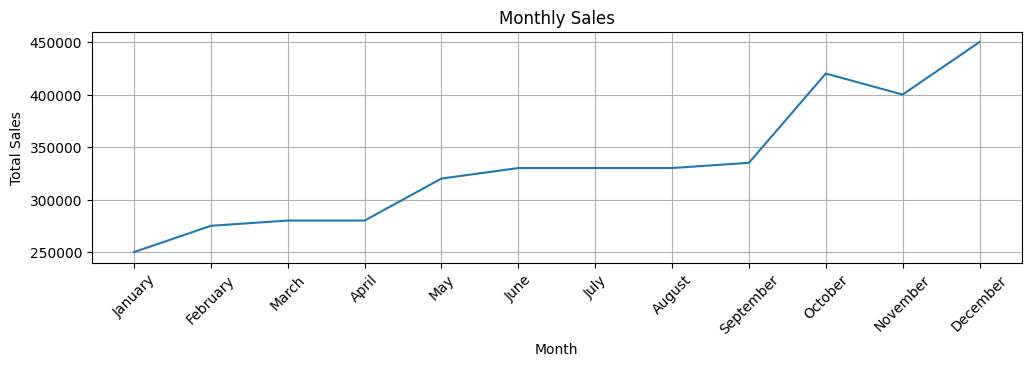

In [131]:
plt.figure(figsize=(12,3))
plt.plot(sales_df['Month'], sales_df['Total_Sales'])
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Monthly Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.savefig('monthly sales.png')
plt.show()

In [110]:
data = {
    'Month': ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],
    'Mumbai_Sales': [240000,245000,245000,310000,310000,315000,450000,460000,455000,550000,540000,560000],
    'Delhi_Sales': [140000,130000,130000,210000,210000,220000,310000,320000,325000,150000,190000,120000],
}
df = pd.DataFrame(data)

#### Bar Plot (Categorical Data)

From here on lets use tips dataset for visualizing the plots

In [111]:
tips = sns.load_dataset('tips')

#### Pie Chart (Categorical Data)

### Histogram (Numerical Data)

### Box Plot (Numerical Data) & (Numeric & Category)

### Scatter Plot (2 - Numerical data vartiables)

### Sub Plots / Multiple Plots

In [112]:
data = {
    'Units_Sold': [5,10,15,20,7,18,6,22,9,4],
    'Unit_Price': [60000,2000,1500,800,62000,1500,12000,900,2500,11000],
    'Total_Sales': [300000,20000,22500,16000,434000,27000,72000,19800,22500,44000]
}
df = pd.DataFrame(data)
df.head(1)

,Units_Sold,Unit_Price,Total_Sales
0,5,60000,300000


<a id="seaborn"> </a>
### 16.Plots using Seaborn

Seaborn is a Python visualization library based on matplotlib. The library provides a high-level interface for plotting statistical graphics. As the library uses matplotlib in the backend, we can use the functions in matplotlib along with functions in seaborn.<br><br>
Various functions in the seaborn library allow us to plot complex and advance statistical plots such as linear/higher-order regression, univariate/multivariate distribution, violin, swarm, strip plots, correlations.

**How to install Seaborn?**<br>
1. You can use-<br>`!pip install seaborn`<br>

#### Hist Plot (numerical variable)

####  Strip Plot (numeric & categorical data)

#### Swarm Plot  (Numerical & Categorical variable)

#### Box Plot -  Numerical variable ,  (Numeric & Categorical variables)

#### Violin Plot  (Numeric & categorical data)

#### Scatter Plot (Numeric & Numeric)

#### Reg Plot (Numeric & Numeric)

#### Rel Plot

#### lmplot

#### Pair Plot (all numerical variables)

<a id="plotly"> </a>
## 17. Plots using Plotly (3d Plots)
Plotly is a python library used to create interactive, publication-quality graphs. Plotly express provides more customizations for plots such as bar plots, histogram, pie plot.

**How to install Plotly?**<br>
1. You can use-<br>
`!pip install plotly`<br>

#### Scatter Plot

#### Histogram

#### Bar

#### Box